In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
pip install numpy matplotlib scikit-learn scikit-image opencv-python


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import os

# Go inside chest_xray folder
data_dir = os.path.join(path, "chest_xray")

train_path = os.path.join(data_dir, "train")
test_path  = os.path.join(data_dir, "test")

print("Train folders:", os.listdir(train_path))
print("Test folders:", os.listdir(test_path))

Train folders: ['PNEUMONIA', 'NORMAL']
Test folders: ['PNEUMONIA', 'NORMAL']


In [ ]:
import cv2
import numpy as np

def load_data(folder):
    images = []
    labels = []

    for label in ["NORMAL", "PNEUMONIA"]:
        path_label = os.path.join(folder, label)
        class_label = 0 if label == "NORMAL" else 1

        for img_name in os.listdir(path_label):
            img_path = os.path.join(path_label, img_name)

            # Read image
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            # Skip broken images
            if img is None:
                continue

            # Resize for consistency
            img = cv2.resize(img, (128, 128))

            images.append(img)
            labels.append(class_label)

    return np.array(images), np.array(labels)

In [ ]:
import os
import kagglehub

# Download latest version to ensure 'path' is defined
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# Go inside chest_xray folder
data_dir = os.path.join(path, "chest_xray")

train_path = os.path.join(data_dir, "train")
test_path  = os.path.join(data_dir, "test")

print("Train folders:", os.listdir(train_path))
print("Test folders:", os.listdir(test_path))

X_train_img, y_train = load_data(train_path)

print("Training Images Shape:", X_train_img.shape)
print("Training Labels Shape:", y_train.shape)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Train folders: ['PNEUMONIA', 'NORMAL']
Test folders: ['PNEUMONIA', 'NORMAL']
Training Images Shape: (5216, 128, 128)
Training Labels Shape: (5216,)


In [ ]:
import cv2
import numpy as np

def load_data(folder):
    images = []
    labels = []

    for label in ["NORMAL", "PNEUMONIA"]:
        path_label = os.path.join(folder, label)
        class_label = 0 if label == "NORMAL" else 1

        for img_name in os.listdir(path_label):
            img_path = os.path.join(path_label, img_name)

            # Read image
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            # Skip broken images
            if img is None:
                continue

            # Resize for consistency
            img = cv2.resize(img, (128, 128))

            images.append(img)
            labels.append(class_label)

    return np.array(images), np.array(labels)

In [ ]:
X_train_img, y_train = load_data(train_path)

print("Training Images Shape:", X_train_img.shape)
print("Training Labels Shape:", y_train.shape)

Training Images Shape: (5216, 128, 128)
Training Labels Shape: (5216,)


In [ ]:
X_test_img, y_test = load_data(test_path)

print("Testing Images Shape:", X_test_img.shape)
print("Testing Labels Shape:", y_test.shape)

Testing Images Shape: (624, 128, 128)
Testing Labels Shape: (624,)


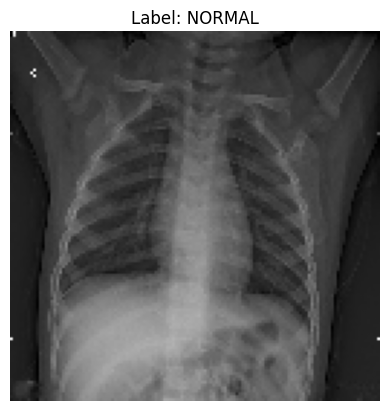

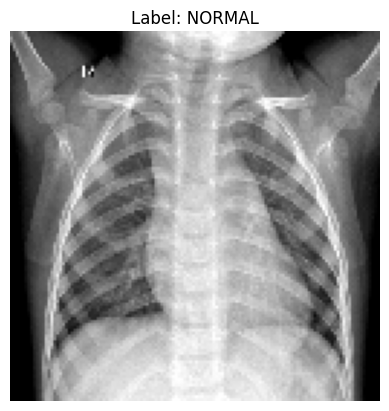

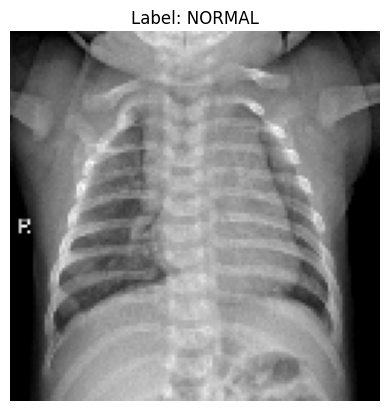

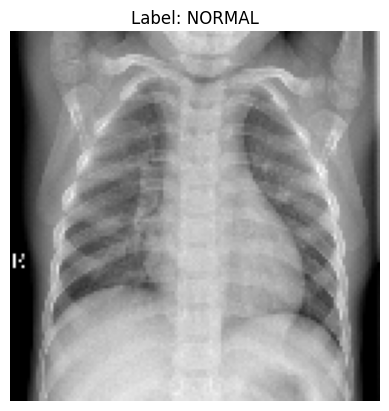

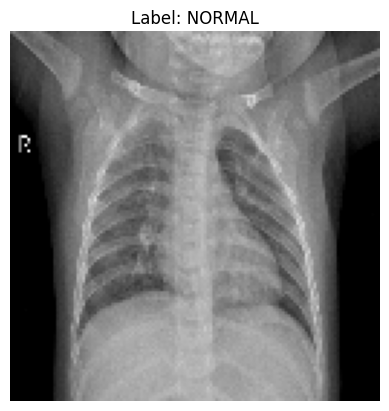

In [ ]:
import matplotlib.pyplot as plt

# Show 5 sample images
for i in range(5):
    plt.imshow(X_train_img[i], cmap='gray')
    plt.title("Label: " + ("NORMAL" if y_train[i] == 0 else "PNEUMONIA"))
    plt.axis('off')
    plt.show()

In [ ]:
from skimage.feature import hog

In [ ]:
def extract_hog(images):
    features = []

    for img in images:
        hog_feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            visualize=False
        )
        features.append(hog_feat)

    return np.array(features)

In [ ]:
X_train_hog = extract_hog(X_train_img)
X_test_hog  = extract_hog(X_test_img)

print("HOG Train Shape:", X_train_hog.shape)
print("HOG Test Shape:", X_test_hog.shape)


HOG Train Shape: (5216, 8100)
HOG Test Shape: (624, 8100)


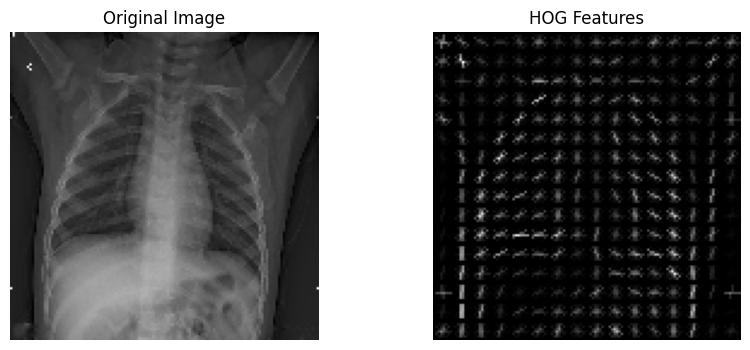

In [ ]:
# Visualize HOG for one image
img = X_train_img[0]

hog_feat, hog_image = hog(
    img,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    visualize=True
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Features")
plt.axis('off')

plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'C': [1, 10, 100], #regularization parameter
    'gamma': [0.001, 0.01, 0.1],  #rbf kernel parameter
    'kernel': ['rbf']
}

In [ ]:
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_hog, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [1, 10, 100], 'gamma': [0.001, 0.01, 0.1],
                         'kernel': ['rbf']},
             verbose=2)

In [ ]:
model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_hog)

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 75 159]
 [  2 388]]
              precision    recall  f1-score   support

           0       0.97      0.32      0.48       234
           1       0.71      0.99      0.83       390

    accuracy                           0.74       624
   macro avg       0.84      0.66      0.66       624
weighted avg       0.81      0.74      0.70       624



In [ ]:
support_indices = model.support_
print("Number of support vectors:", len(support_indices))

Number of support vectors: 1114


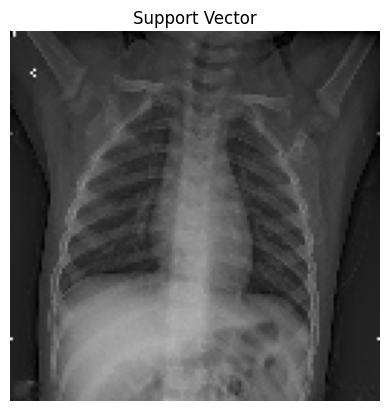

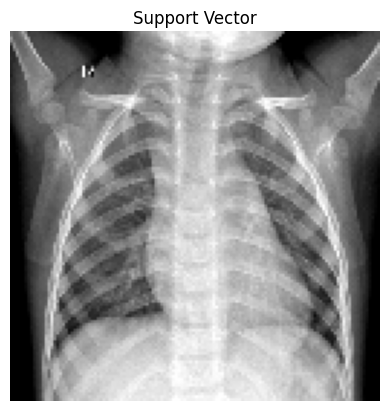

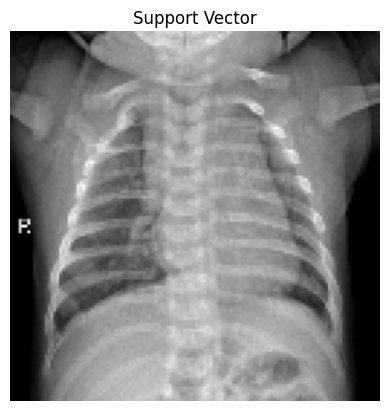

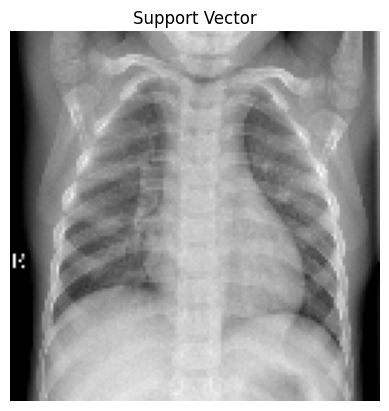

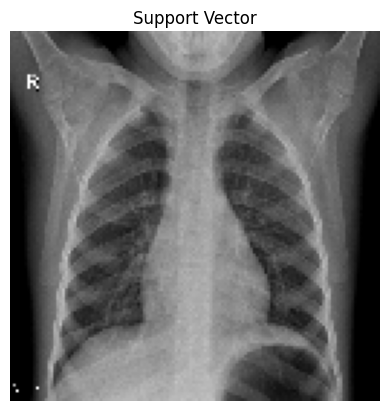

In [ ]:
import matplotlib.pyplot as plt

for i in support_indices[:5]:  # show first 5
    plt.imshow(X_train_img[i], cmap='gray')
    plt.title("Support Vector")
    plt.axis('off')
    plt.show()


In [ ]:
from skimage.feature import hog

def get_hog_image(img):
    hog_feat, hog_image = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=True
    )
    return hog_image

In [ ]:
import cv2

def overlay_hog(original, hog_img):
    hog_resized = cv2.resize(hog_img, (128, 128))

    # Normalize HOG image
    hog_resized = cv2.normalize(hog_resized, None, 0, 255, cv2.NORM_MINMAX)
    hog_resized = np.uint8(hog_resized)

    # Convert grayscale to color
    original_color = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)
    hog_color = cv2.cvtColor(hog_resized, cv2.COLOR_GRAY2BGR)

    # Overlay
    overlay = cv2.addWeighted(original_color, 0.6, hog_color, 0.4, 0)

    return overlay

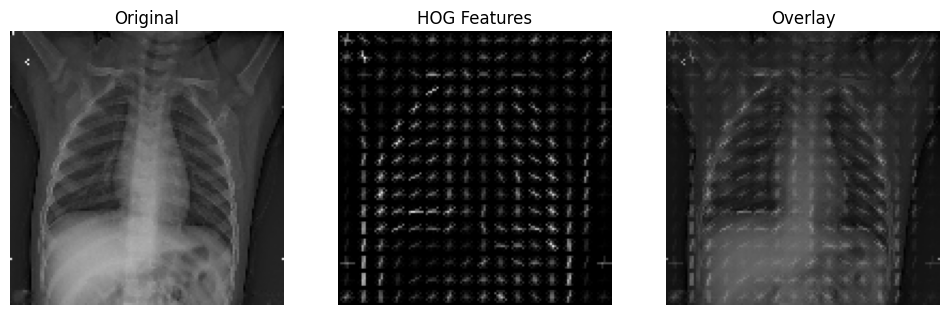

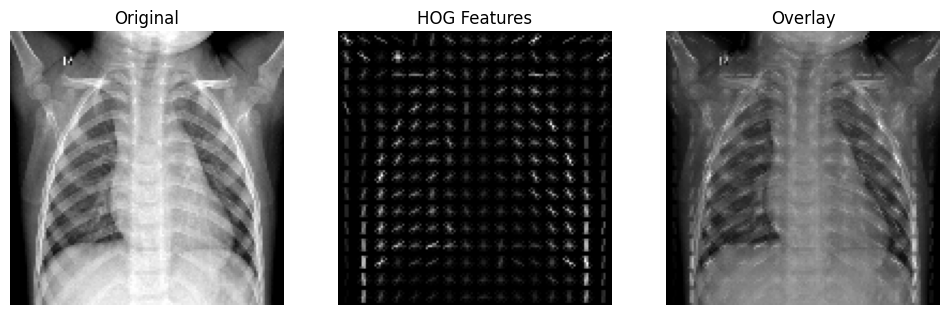

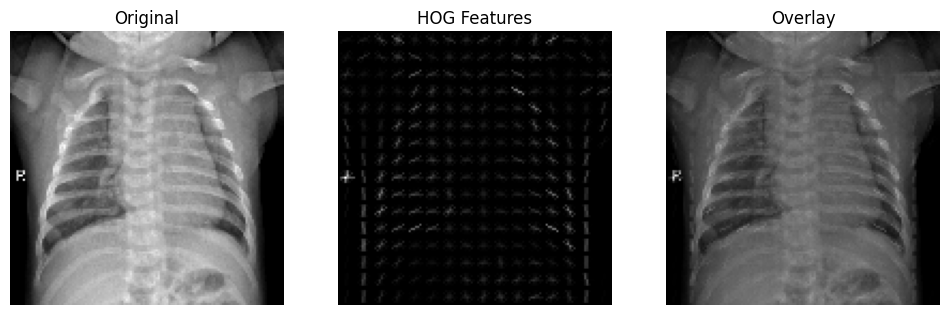

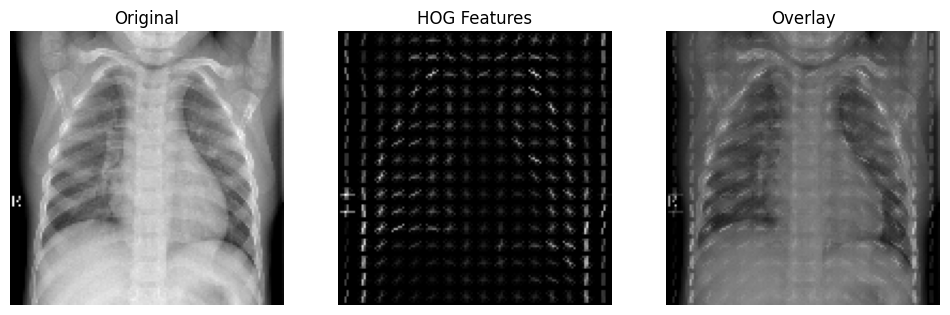

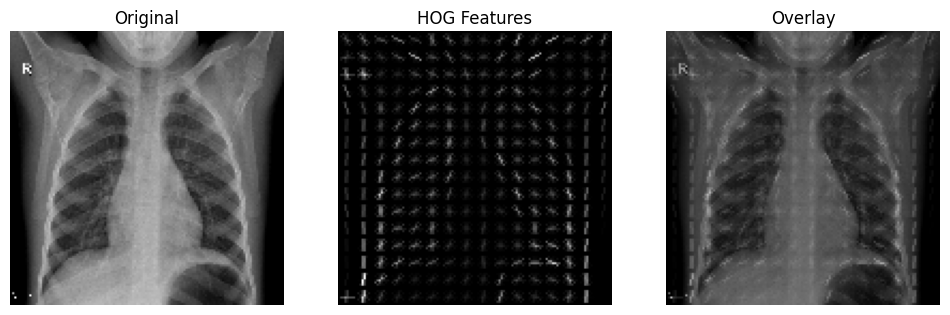

In [ ]:
import matplotlib.pyplot as plt

for i in support_indices[:5]:  # first 5 support vectors

    original = X_train_img[i]
    hog_img = get_hog_image(original)
    overlay = overlay_hog(original, hog_img)

    plt.figure(figsize=(12,4))

    # Original
    plt.subplot(1,3,1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # HOG
    plt.subplot(1,3,2)
    plt.imshow(hog_img, cmap='gray')
    plt.title("HOG Features")
    plt.axis('off')

    # Overlay
    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis('off')

    plt.show()